#Netflix Shows Analysis

## 1.Load the Data and understand it.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("netflix_data.csv")
df.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [3]:
df.shape#display number of rows and columns

(8790, 10)

In [4]:
df.info()#see column names and datatype

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8790 non-null   object
 1   type          8790 non-null   object
 2   title         8790 non-null   object
 3   director      8790 non-null   object
 4   country       8790 non-null   object
 5   date_added    8790 non-null   object
 6   release_year  8790 non-null   int64 
 7   rating        8790 non-null   object
 8   duration      8790 non-null   object
 9   listed_in     8790 non-null   object
dtypes: int64(1), object(9)
memory usage: 686.8+ KB


In [5]:
df.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [6]:
df.isnull().sum()#to check the null values in the dataset

,0
show_id,0
type,0
title,0
director,0
country,0
date_added,0
release_year,0
rating,0
duration,0
listed_in,0


## 2.Clean the Data

In [7]:
#Make the date column to DATE datatype
df['date_added']=pd.to_datetime(df['date_added'])

#Pull out the year and month column from date_added
df['year_added']=df['date_added'].dt.year
df['month_added']=df['date_added'].dt.month

print(df['year_added'].head())
print(df['month_added'].head())

0    2021
1    2021
2    2021
3    2021
4    2021
Name: year_added, dtype: int32
0    9
1    9
2    9
3    9
4    9
Name: month_added, dtype: int32


In [8]:
df.duplicated().sum()#Check for duplicates

np.int64(0)

In [9]:
#converting the duration from string datatype to number
movies=df.query("type=='Movie'").copy()
movies['duration']=movies['duration'].str.replace(' min','').astype('int')
movies.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90,Documentaries,2021,9
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91,"Children & Family Movies, Comedies",2021,9
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125,"Dramas, Independent Movies, International Movies",2021,9
6,s10,Movie,The Starling,Theodore Melfi,United States,2021-09-24,2021,PG-13,104,"Comedies, Dramas",2021,9
7,s939,Movie,Motu Patlu in the Game of Zones,Suhas Kadav,India,2021-05-01,2019,TV-Y7,87,"Children & Family Movies, Comedies, Music & Mu...",2021,5


In [10]:
shows=df.query("type=='TV Show'").copy()
shows['seasons']=shows['duration'].str.replace(' Seasons','').str.replace(' Season','').str.replace('s','').astype('int')
shows.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,year_added,month_added,seasons
1,s3,TV Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",2021,9,1
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",2021,9,1
5,s9,TV Show,The Great British Baking Show,Andy Devonshire,United Kingdom,2021-09-24,2021,TV-14,9 Seasons,"British TV Shows, Reality TV",2021,9,9
17,s4,TV Show,Jailbirds New Orleans,Not Given,Pakistan,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV",2021,9,1
18,s15,TV Show,Crime Stories: India Detectives,Not Given,Pakistan,2021-09-22,2021,TV-MA,1 Season,"British TV Shows, Crime TV Shows, Docuseries",2021,9,1


In [11]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'year_added',
       'month_added'],
      dtype='object')

##3.EDA

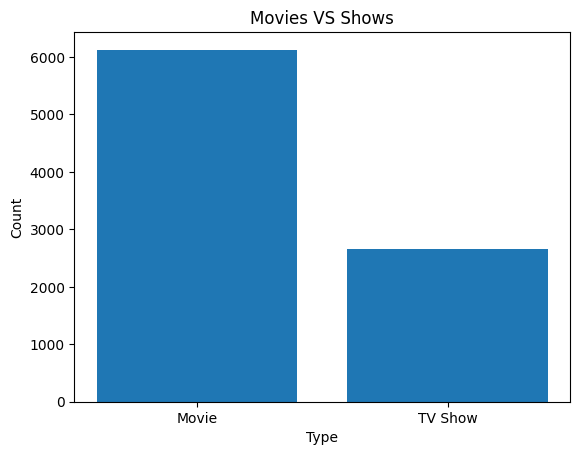

In [12]:
#which type has the most counts
counts=df['type'].value_counts()

plt.bar(counts.index,counts.values)
plt.xlabel('Type')
plt.ylabel('Count')
plt.title('Movies VS Shows')
plt.show()

In [13]:
type_year=df.groupby(['type','year_added']).size().unstack()
type_year

year_added,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
type,,,,,,,,,,,,,,
Movie,1.0,2.0,1.0,13.0,3.0,6.0,19.0,56.0,251.0,836.0,1237.0,1424.0,1284.0,993.0
TV Show,1.0,NaN,NaN,NaN,NaN,5.0,5.0,26.0,175.0,349.0,411.0,592.0,595.0,505.0


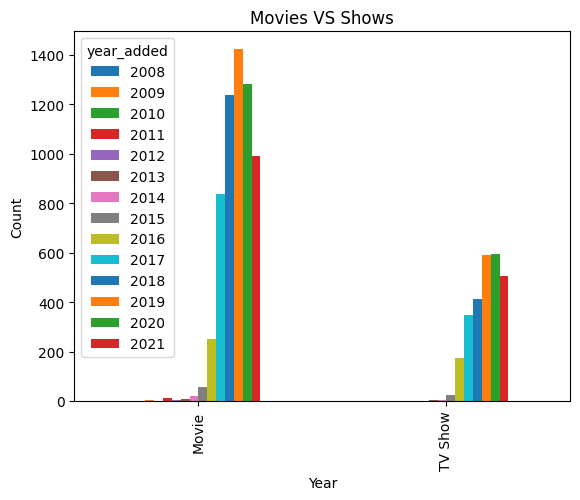

In [14]:
type_year=df.groupby(['type','year_added']).size().unstack()
type_year.plot(kind='bar')
plt.xlabel('Year')
plt.ylabel('Count')
plt.title('Movies VS Shows')
plt.show()

In [15]:
Year_count=df['year_added'].value_counts().sort_index()
Year_count

,count
year_added,
2008,2
2009,2
2010,1
2011,13
2012,3
2013,11
2014,24
2015,82
2016,426


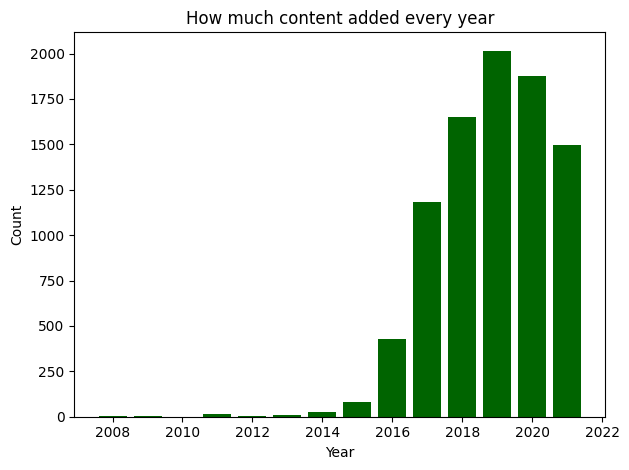

In [16]:
plt.bar(Year_count.index,Year_count.values,color='darkgreen')
plt.xlabel('Year')
plt.ylabel('Count')
plt.title('How much content added every year')
plt.tight_layout()
plt.show()

In [17]:
month_counts=df['month_added'].value_counts().sort_index()
print(month_counts)

month_names=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

month_added
1     737
2     562
3     741
4     763
5     632
6     728
7     827
8     754
9     769
10    760
11    705
12    812
Name: count, dtype: int64


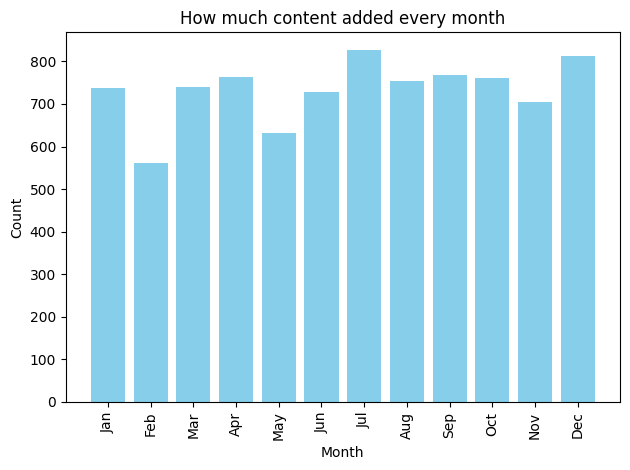

In [18]:
plt.bar(month_names,month_counts.values,color='Skyblue')
plt.xticks(rotation=90)
plt.xlabel('Month')
plt.ylabel('Count')
plt.title('How much content added every month')
plt.tight_layout()
plt.show()

In [19]:
df['country'].unique()

array(['United States', 'France', 'Brazil', 'United Kingdom', 'India',
       'Germany', 'Pakistan', 'Not Given', 'China', 'South Africa',
       'Japan', 'Nigeria', 'Spain', 'Philippines', 'Australia',
       'Argentina', 'Canada', 'Hong Kong', 'Italy', 'New Zealand',
       'Egypt', 'Colombia', 'Mexico', 'Belgium', 'Switzerland', 'Taiwan',
       'Bulgaria', 'Poland', 'South Korea', 'Saudi Arabia', 'Thailand',
       'Indonesia', 'Kuwait', 'Malaysia', 'Vietnam', 'Lebanon', 'Romania',
       'Syria', 'United Arab Emirates', 'Sweden', 'Mauritius', 'Austria',
       'Turkey', 'Czech Republic', 'Cameroon', 'Netherlands', 'Ireland',
       'Russia', 'Kenya', 'Chile', 'Uruguay', 'Bangladesh', 'Portugal',
       'Hungary', 'Norway', 'Singapore', 'Iceland', 'Serbia', 'Namibia',
       'Peru', 'Mozambique', 'Ghana', 'Zimbabwe', 'Israel', 'Finland',
       'Denmark', 'Paraguay', 'Cambodia', 'Georgia', 'Soviet Union',
       'Greece', 'West Germany', 'Iran', 'Venezuela', 'Slovenia',
       'Gua

In [20]:
df['primary_country']=df['country'].str.split(',').str[0]
df = df[df['primary_country'] != 'Not Given']

In [21]:
top_countries=df['primary_country'].value_counts().head(10)
print(top_countries)


primary_country
United States     3240
India             1057
United Kingdom     638
Pakistan           421
Canada             271
Japan              259
South Korea        214
France             213
Spain              182
Mexico             138
Name: count, dtype: int64


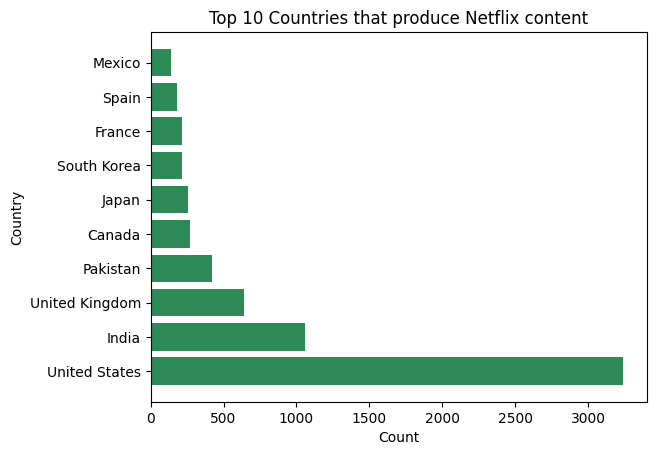

In [22]:
plt.barh(top_countries.index,top_countries.values,color='seagreen')
plt.title('Top 10 Countries that produce Netflix content')
plt.xlabel('Count')
plt.ylabel('Country')
plt.show()

In [23]:
rating_counts=df['rating'].value_counts()
rating_counts

,count
rating,
TV-MA,3111
TV-14,2065
TV-PG,835
R,791
PG-13,487
TV-Y7,308
TV-Y,284
PG,282
TV-G,209


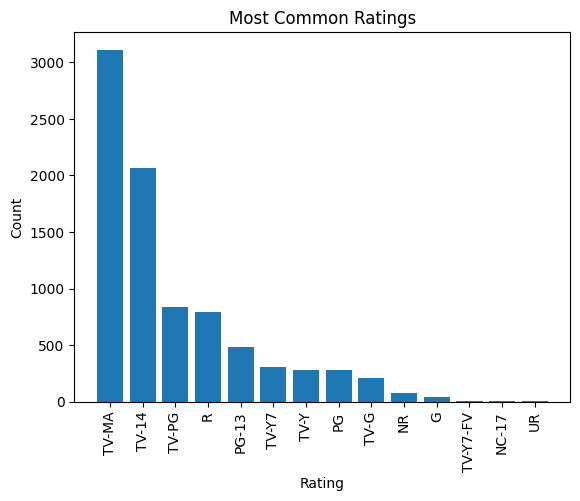

In [24]:
plt.bar(rating_counts.index,rating_counts.values)
plt.xticks(rotation=90)
plt.title('Most Common Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

In [25]:
all_genres = df['listed_in'].str.split(', ').explode()
all_genres.head()

,listed_in
0,Documentaries
1,Crime TV Shows
1,International TV Shows
1,TV Action & Adventure
2,TV Dramas


In [26]:
top_genre=all_genres.value_counts().sort_index().head(10)
top_genre

,count
listed_in,
Action & Adventure,823
Anime Features,64
Anime Series,173
British TV Shows,251
Children & Family Movies,591
Classic & Cult TV,25
Classic Movies,115
Comedies,1623
Crime TV Shows,464


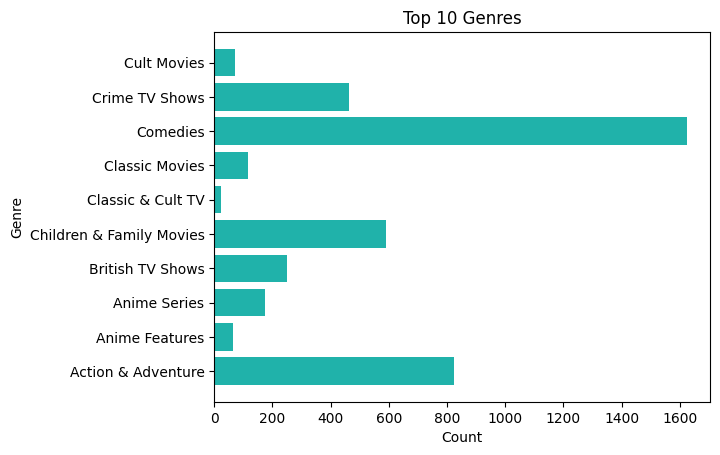

In [27]:
plt.barh(top_genre.index,top_genre.values,color='lightseagreen')
plt.title('Top 10 Genres')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.show()

In [28]:
movies = df[df['type'] == 'Movie'].copy()
movies

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,year_added,month_added,primary_country
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries,2021,9,United States
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies",2021,9,Brazil
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies",2021,9,United States
6,s10,Movie,The Starling,Theodore Melfi,United States,2021-09-24,2021,PG-13,104 min,"Comedies, Dramas",2021,9,United States
7,s939,Movie,Motu Patlu in the Game of Zones,Suhas Kadav,India,2021-05-01,2019,TV-Y7,87 min,"Children & Family Movies, Comedies, Music & Mu...",2021,5,India
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8702,s8232,Movie,The Bund,Not Given,Hong Kong,2018-09-20,1983,TV-14,103 min,"Action & Adventure, Dramas, International Movies",2018,9,Hong Kong
8707,s8269,Movie,The Darkest Dawn,Not Given,United Kingdom,2018-06-23,2016,TV-MA,75 min,"Action & Adventure, Independent Movies, Intern...",2018,6,United Kingdom
8716,s8331,Movie,The Great Battle,Not Given,South Korea,2019-04-08,2018,TV-MA,136 min,"Action & Adventure, Dramas, International Movies",2019,4,South Korea
8763,s8648,Movie,"Twisted Trunk, Big Fat Body",Not Given,India,2017-01-15,2015,TV-14,89 min,"Dramas, International Movies",2017,1,India


In [29]:
movies['duration_mins'] = movies['duration'].str.replace(' min', '').astype(int)
movies['duration_mins'].head()

,duration_mins
0,90
3,91
4,125
6,104
7,87


In [30]:
avg_duration = movies['duration_mins'].mean()
print(avg_duration)

99.89436019764867


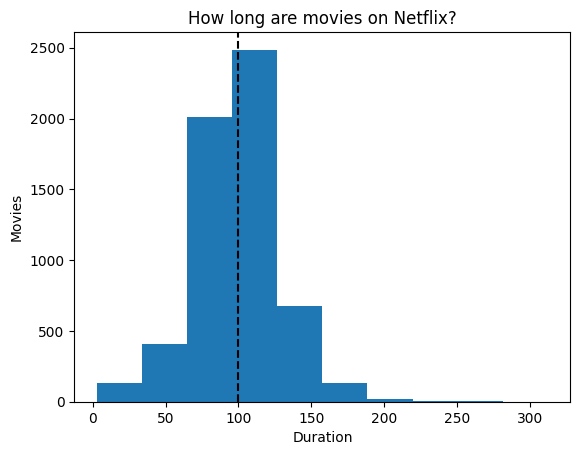

In [31]:
plt.hist(movies['duration_mins'])
plt.axvline(avg_duration,linestyle='--',color='black')
plt.title('How long are movies on Netflix?')
plt.xlabel('Duration')
plt.ylabel('Movies')
plt.show()

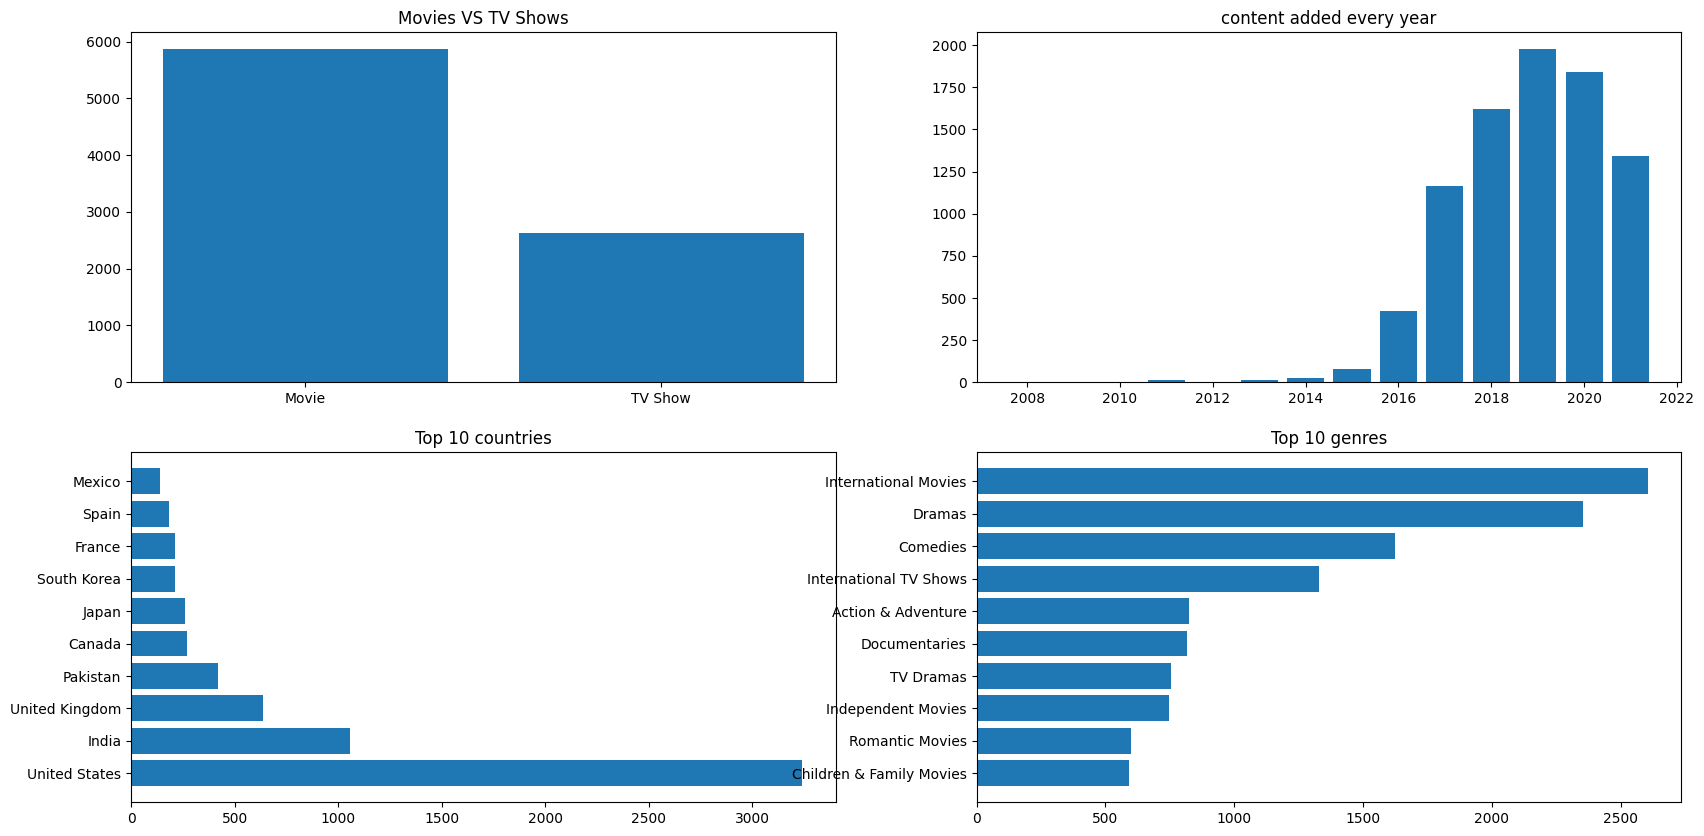

In [35]:
fig,axes=plt.subplots(2,2,figsize=(20,10))

type_counts=df['type'].value_counts()
axes[0][0].bar(type_counts.index,type_counts.values)
axes[0][0].set_title('Movies VS TV Shows')

yearly_counts=df['year_added'].value_counts().sort_index()
axes[0][1].bar(yearly_counts.index,yearly_counts.values)
axes[0][1].set_title('content added every year')


top_countries_counts=df['primary_country'].value_counts().head(10)
axes[1][0].barh(top_countries_counts.index,top_countries_counts.values)
axes[1][0].set_title('Top 10 countries')

top_genres_counts=all_genres.value_counts().head(10)
axes[1][1].barh(top_genres_counts.index,top_genres_counts.values)
axes[1][1].set_title('Top 10 genres')
axes[1][1].invert_yaxis()

#key Findings
<ol>

<li>Netflix added very little content before 2015, but saw rapid growth after that, reaching a peak around 2019. After this, growth slowed slightly.

<li>Movies make up most of the content on Netflix. However, TV shows have been increasing faster in recent years.

<li>More content is added during July and December, while February has the least additions. This suggests Netflix releases more content during high-viewing periods.

<li>Most content comes from the United States, followed by India and the United Kingdom. This shows that a few countries dominate content production.

<li>Most content is rated TV-MA and TV-14, meaning Netflix mainly targets adults and young audiences. There is less content for kids.

<li>Comedy is the most common genre, followed by Action & Adventure and Family content. This shows Netflix focuses on comey genre.

<li>Most movies are between 80–120 minutes, with an average of about 99 minutes, which is a standard movie length.

#Recommendations
<ul>
<li>Netflix should invest more in original TV shows and long-form content
<li> Prioritise genres like Comedies, Action, Adventure, Children and Family movies over other genres.
<li>Continue focusing on Adult and young audiences but gradually increase Kids/family content for wider reach.
<li>Shchedule major releases during high engagement periods(July and December)-holidays or mid-year
<li>Stick to the average duration 99 mins for movies as they match audience preference.
